In [1]:
# NuMI_Flux: post-selection true neutrino energy (MC only, POT-corrected)
# Outputs are saved to ./pdf and ./jpeg as for the other observables.
import os
import sys
workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../..")
from analysis import Analysis

data_file = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/\U0001F3DB PhD Repository/\U0001F680 Research/\U0001F916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root'


Found NaN category in Sample `mc` with 198 occurrence(s). Masking NaNs...

Processing systematics for sample: mc
Setting weight for mc to 1.00e+00


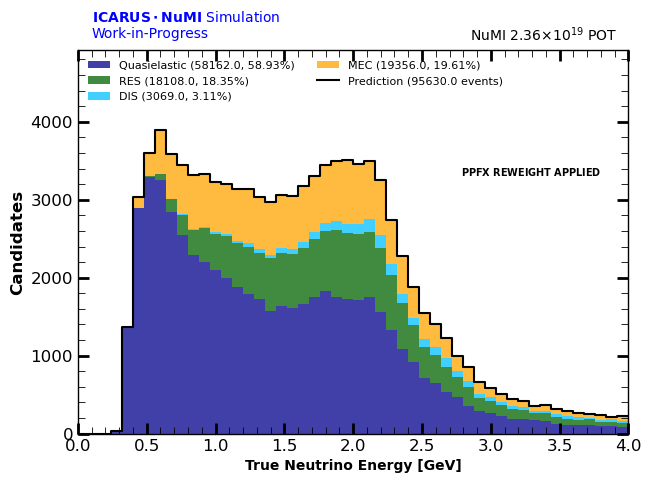

In [8]:
analysis = Analysis('nu_energy.toml', data_file)
analysis.run(close_figs=False)

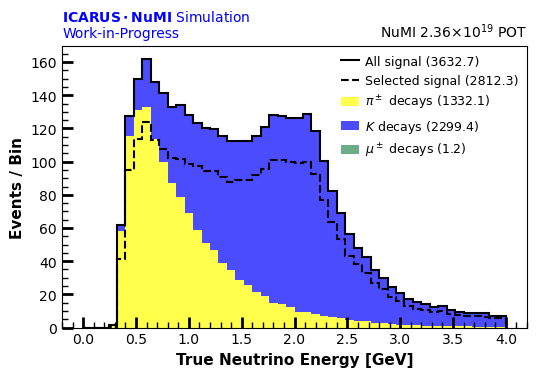

Saved: nu_energy_parent_decomposition


In [33]:
# Parent decomposition of the true neutrino energy spectrum.
# Shows that the double-peak structure exists BEFORE selection and maps onto
# the neutrino parent species (pion decays -> low peak, kaon decays -> ~2 GeV
# peak), and that the selection scales the spectrum without reshaping it.
# Top panel: all true signal events (signal tree) split by parent, with the
# truth-matched selected signal overlaid. Bottom panel: selection efficiency
# vs true neutrino energy.
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

OUT_DIR = os.getcwd()

ONBEAM_POT, NOMINAL_POT = 2.36124e19, 7.178e20
mc_scale = ONBEAM_POT / NOMINAL_POT
BINS = np.linspace(0, 4, 51)
CENTERS = 0.5 * (BINS[:-1] + BINS[1:])

f = uproot.open(data_file)
sig = f['events/nominal/signal'].arrays(['true_neutrino_energy', 'true_parent_pdg'], library='np')
sel = f['events/nominal/selected'].arrays(['true_neutrino_energy', 'true_parent_pdg', 'true_category'], library='np')

# truth-matched signal events in the selected sample (signal categories)
is_sig = np.isin(sel['true_category'], [0, 1, 3, 4])
e_sel = sel['true_neutrino_energy'][is_sig]

e_all = sig['true_neutrino_energy']
par = np.abs(sig['true_parent_pdg'])

PARENTS = [
    (np.isin(par, [211]),           r'$\pi^\pm$ decays', 'yellow'),
    (np.isin(par, [321, 130, 310]), r'$K$ decays',        'blue'),
    (np.isin(par, [13]),            r'$\mu^\pm$ decays', '#2E8B57'),
]

fig = plt.figure(figsize=(6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])
#axr = fig.add_subplot(gs[1], sharex=ax)

bottom = np.zeros(len(CENTERS))
for mask, label, color in PARENTS:
    h, _ = np.histogram(e_all[mask], bins=BINS)
    h = h * mc_scale
    ax.bar(CENTERS, h, width=np.diff(BINS), bottom=bottom, color=color,
           alpha=0.7, label=f'{label} ({h.sum():.1f})')
    bottom += h

h_all, _ = np.histogram(e_all, bins=BINS)
h_all = h_all * mc_scale
h_sel, _ = np.histogram(e_sel, bins=BINS)
h_sel = h_sel * mc_scale
ax.stairs(h_all, BINS, color='black', linewidth=1.5,
          label=f'All signal ({h_all.sum():.1f})')
ax.stairs(h_sel, BINS, color='black', linewidth=1.5, linestyle='--',
          label=f'Selected signal ({h_sel.sum():.1f})')

ax.set_ylabel('Events / Bin', fontsize=11, fontweight='bold', fontfamily='sans-serif')
ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontfamily('sans-serif')
# plt.setp(ax.get_xticklabels(), visible=False)  # only when the ratio panel is drawn below
ax.legend(fontsize=9, loc='upper right', ncol=1, framealpha=0.0, edgecolor='none',
          columnspacing=1.0, handlelength=1.4, handletextpad=0.5, borderaxespad=0.3)
ax.text(ax.get_xlim()[0], ax.get_ylim()[1] * 1.02,
        r'$\bf{ICARUS \cdot NuMI}$ Simulation' + '\nWork-in-Progress',
        fontsize=10, color='blue', verticalalignment='bottom', fontfamily='sans-serif')
ax.text(ax.get_xlim()[1], ax.get_ylim()[1] * 1.02,
        f'NuMI {ONBEAM_POT/1e19:.2f}' + r'$\times 10^{19}$ POT',
        fontsize=10, color='black', verticalalignment='bottom', horizontalalignment='right', fontfamily='sans-serif')

with np.errstate(invalid='ignore', divide='ignore'):
    eff = np.where(h_all > 0, h_sel / h_all, np.nan)
ax.set_xlabel('True Neutrino Energy [GeV]', fontsize=11, fontweight='bold', fontfamily='sans-serif')

for sub in ('pdf', 'jpeg'):
    os.makedirs(os.path.join(OUT_DIR, sub), exist_ok=True)
fig.savefig(os.path.join(OUT_DIR, 'pdf/nu_energy_parent_decomposition.pdf'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(OUT_DIR, 'jpeg/nu_energy_parent_decomposition.jpeg'), bbox_inches='tight', dpi=300)
plt.show()
print('Saved: nu_energy_parent_decomposition')


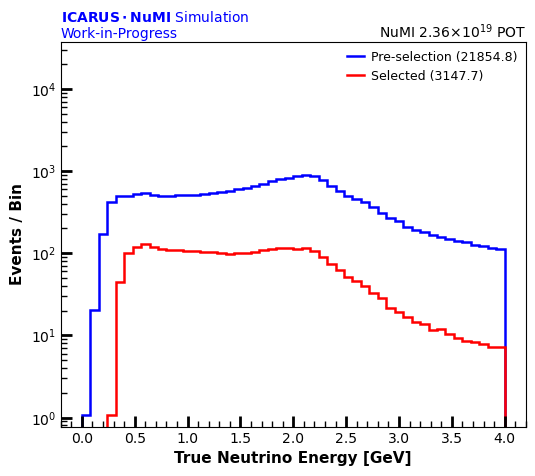

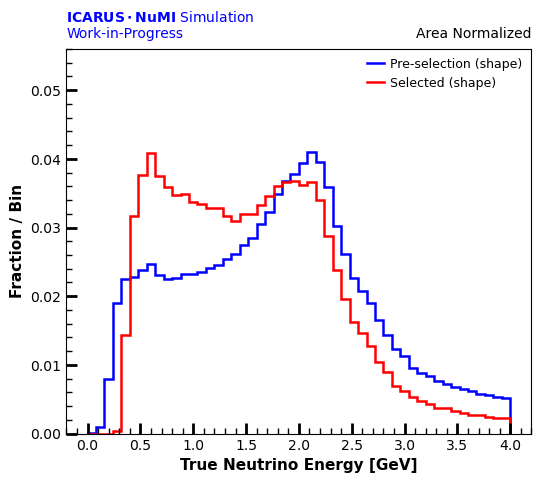

Saved: nu_energy_presel_vs_selected_abs / _shape (pre 21854.8, sel 3147.7)


In [35]:
# Pre-selection vs post-selection true neutrino energy, both POT-normalized
# to the data exposure (2.36124e19 POT). Only entries matched to a true
# neutrino (finite true energy) enter. Two figures, same format as the
# parent decomposition plot: absolute rates (log scale) and area-normalized
# shape comparison.
import uproot
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = os.getcwd()
ONBEAM_POT, NOMINAL_POT = 2.36124e19, 7.178e20
mc_scale = ONBEAM_POT / NOMINAL_POT
BINS = np.linspace(0, 4, 51)
CENTERS = 0.5 * (BINS[:-1] + BINS[1:])

f = uproot.open(data_file)
e_pre = f['events/nominal/preselection'].arrays(['true_neutrino_energy'], library='np')['true_neutrino_energy']
e_pre = e_pre[np.isfinite(e_pre)]
e_sel = f['events/nominal/selected'].arrays(['true_neutrino_energy'], library='np')['true_neutrino_energy']
e_sel = e_sel[np.isfinite(e_sel)]

h_pre, _ = np.histogram(e_pre, bins=BINS)
h_sel, _ = np.histogram(e_sel, bins=BINS)
h_pre_pot = h_pre * mc_scale
h_sel_pot = h_sel * mc_scale


def style_axes(ax, ylabel, right_label):
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold', fontfamily='sans-serif')
    ax.set_xlabel('True Neutrino Energy [GeV]', fontsize=11, fontweight='bold', fontfamily='sans-serif')
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.legend(fontsize=9, loc='upper right', ncol=1, framealpha=0.0, edgecolor='none',
              columnspacing=1.0, handlelength=1.4, handletextpad=0.5, borderaxespad=0.3)
    ax.text(ax.get_xlim()[0], ax.get_ylim()[1] * 1.02,
            r'$\bf{ICARUS \cdot NuMI}$ Simulation' + '\nWork-in-Progress',
            fontsize=10, color='blue', verticalalignment='bottom', fontfamily='sans-serif')
    ax.text(ax.get_xlim()[1], ax.get_ylim()[1] * 1.02,
            right_label,
            fontsize=10, color='black', verticalalignment='bottom',
            horizontalalignment='right', fontfamily='sans-serif')


# --- Figure 1: POT-normalized absolute comparison (log scale) ---
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)
ax.stairs(h_pre_pot, BINS, color='blue', linewidth=1.8,
          label=f'Pre-selection ({h_pre_pot.sum():.1f})')
ax.stairs(h_sel_pot, BINS, color='red', linewidth=1.8,
          label=f'Selected ({h_sel_pot.sum():.1f})')
ax.set_yscale('log')
ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] * 30)
style_axes(ax, 'Events / Bin', f'NuMI {ONBEAM_POT/1e19:.2f}' + r'$\times 10^{19}$ POT')
fig.savefig(os.path.join(OUT_DIR, 'pdf/nu_energy_presel_vs_selected_abs.pdf'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(OUT_DIR, 'jpeg/nu_energy_presel_vs_selected_abs.jpeg'), bbox_inches='tight', dpi=300)
plt.show()

# --- Figure 2: area-normalized shape comparison ---
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)
ax.stairs(h_pre / max(h_pre.sum(), 1), BINS, color='blue', linewidth=1.8,
          label='Pre-selection (shape)')
ax.stairs(h_sel / max(h_sel.sum(), 1), BINS, color='red', linewidth=1.8,
          label='Selected (shape)')
ax.set_ylim(0, ax.get_ylim()[1] * 1.3)
style_axes(ax, 'Fraction / Bin', 'Area Normalized')
fig.savefig(os.path.join(OUT_DIR, 'pdf/nu_energy_presel_vs_selected_shape.pdf'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(OUT_DIR, 'jpeg/nu_energy_presel_vs_selected_shape.jpeg'), bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved: nu_energy_presel_vs_selected_abs / _shape (pre {h_pre_pot.sum():.1f}, sel {h_sel_pot.sum():.1f})')
